In [1]:
import sys
from importlib.metadata import entry_points

print(sys.executable)

/global/u2/r/ritaferi/HADES_DATA/.pixi/envs/default/bin/python


In [2]:
%cd /global/u2/r/ritaferi/HADES_DATA

/global/u2/r/ritaferi/HADES_DATA


In [6]:
%%writefile SIM_PROVA/scene.yaml
fine_mesh: true
window_size: [1200, 900]
export_scale: 1
export_and_exit: "SIM_PROVA/hades.png"

Overwriting SIM_PROVA/scene.yaml


In [38]:
import math
import subprocess
import sys
from pathlib import Path

# File GDML
gdml_file = Path("SIM_PROVA/hades.gdml")

# Cartella delle immagini
output_dir = Path("SIM_PROVA/views")
output_dir.mkdir(parents=True, exist_ok=True)

# Distanza della telecamera:
# diminuire per aumentare lo zoom
# aumentare se la geometria viene tagliata
camera_distance = 1000

# Altezza della telecamera rispetto al centro
camera_height = 250

image_paths = []

for index in range(2):

    angle_deg = index * 90
    angle_rad = math.radians(angle_deg)

    camera_x = camera_distance * math.sin(angle_rad)
    camera_y = -camera_distance * math.cos(angle_rad)
    camera_z = camera_height

    scene_file = output_dir / f"scene_{index + 1}.yaml"
    image_file = output_dir / f"view_{index + 1}.png"

    scene_content = f"""
fine_mesh: true

window_size: [1000, 800]
export_scale: 1

default:
  focus: [0, 0, 0]
  up: [0, 0, 1]
  camera: [{camera_x:.3f}, {camera_y:.3f}, {camera_z:.3f}]
  parallel: false

export_and_exit: "{image_file}"
"""

    scene_file.write_text(scene_content)

    print(f"Genero vista {index + 1}/2 - angolo {angle_deg}°")

    command = [
        sys.executable,
        "-c",
        "from pygeomtools.viewer import vis_gdml_cli; vis_gdml_cli()",
        str(gdml_file),
        "--scene",
        str(scene_file),
    ]

    subprocess.run(command, check=True)

    image_paths.append(image_file)

print("\nGenerazione completata.")

Genero vista 1/2 - angolo 0°


2026-09-18 06:09:26.824 (   4.311s) [    7F93C9C01B80]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


Genero vista 2/2 - angolo 90°


2026-09-18 06:09:33.598 (   4.746s) [    7F7238C07B80]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=



Generazione completata.


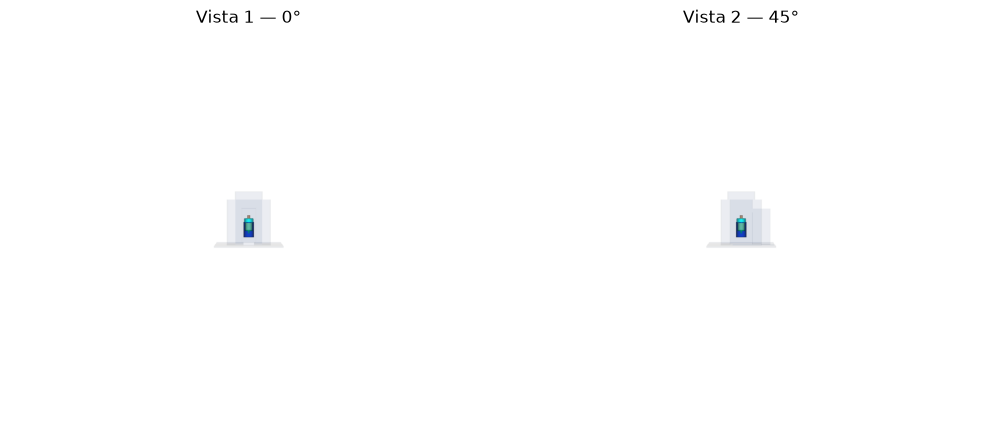

In [39]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1,2, figsize=(10,5))

for index, (axis, image_path) in enumerate(
    zip(axes.flat, image_paths)
):
    image = Image.open(image_path)

    axis.imshow(image)
    axis.set_title(f"Vista {index + 1} — {index * 45}°")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [40]:
from pathlib import Path
from PIL import Image

views_dir = Path("SIM_PROVA/views")

# 1.0 = nessuno zoom
# 1.5 = zoom moderato
# 2.0 = zoom forte
zoom_factor = 10

zoomed_paths = []

for index in range(2):

    input_path = views_dir / f"view_{index + 1}.png"
    output_path = views_dir / f"view_{index + 1}_zoom.png"

    image = Image.open(input_path)

    width, height = image.size

    # Dimensioni della regione da conservare
    cropped_width = int(width / zoom_factor)
    cropped_height = int(height / zoom_factor)

    # Centro dell'immagine
    center_x = width // 2
    center_y = height // 2

    left = center_x - cropped_width // 2
    upper = center_y - cropped_height // 2
    right = center_x + cropped_width // 2
    lower = center_y + cropped_height // 2

    # Ritaglia la parte centrale
    cropped = image.crop((left, upper, right, lower))

    # Riporta il ritaglio alla risoluzione originale
    zoomed = cropped.resize(
        (width, height),
        Image.Resampling.LANCZOS,
    )

    zoomed.save(output_path)

    zoomed_paths.append(output_path)

    print(f"Creata: {output_path}")

Creata: SIM_PROVA/views/view_1_zoom.png
Creata: SIM_PROVA/views/view_2_zoom.png


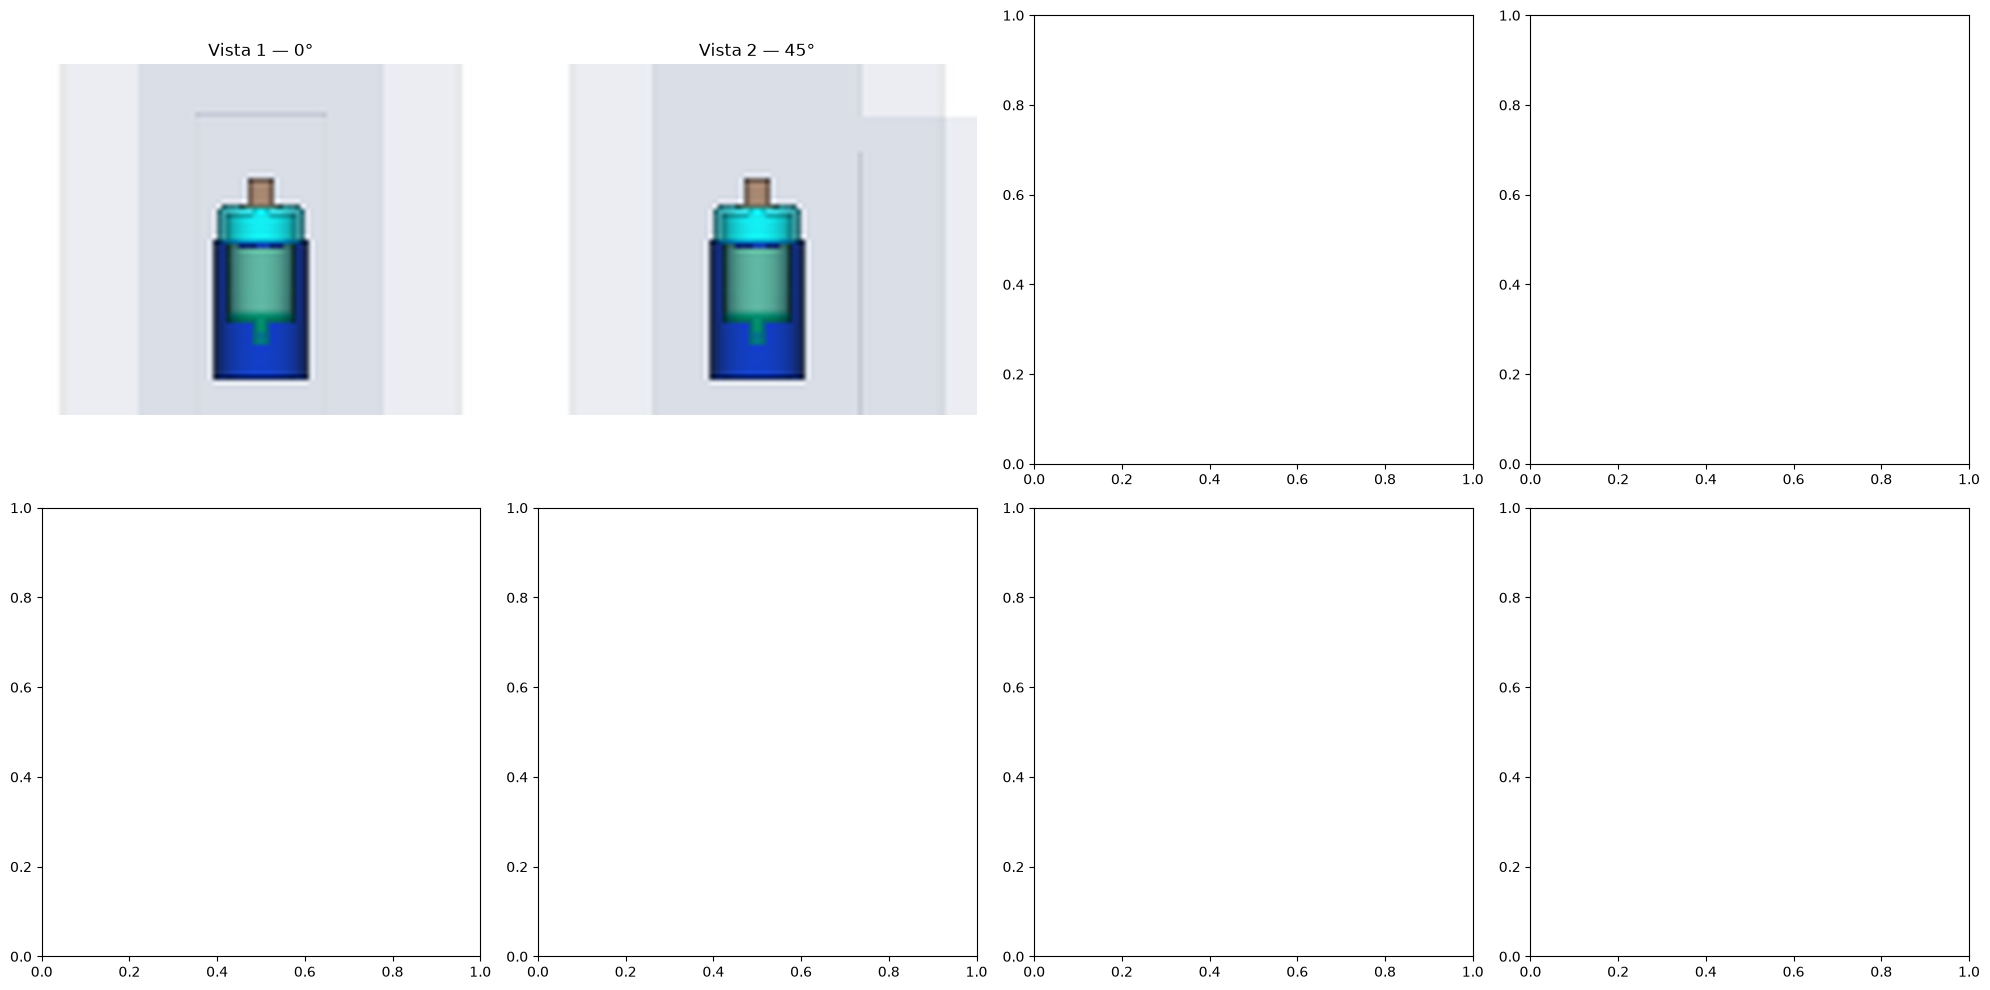

In [41]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for index, (axis, image_path) in enumerate(
    zip(axes.flat, zoomed_paths)
):
    image = Image.open(image_path)

    axis.imshow(image)
    axis.set_title(
        f"Vista {index + 1} — {index * 45}°"
    )
    axis.axis("off")

plt.tight_layout()
plt.show()